In [2]:
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):
    """ 
    Returns a specific index t of a passed list of values vals
    while considering the batch dimension.
    """
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def forward_diffusion_sample(x_0, t, device="cpu"):
    """ 
    Takes an image and a timestep as input and 
    returns the noisy version of it
    """
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    # mean + variance
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)


# Define beta schedule
T = 300
betas = linear_beta_schedule(timesteps=T)

# Pre-calculate different terms for closed form
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

In [3]:
# import os
# import pydicom as dicom
# from pydicom.pixel_data_handlers.util import apply_voi_lut
# import numpy as np
# import cv2
# InitialDir = 'D:/PetStuff/manifest-1608669183333/Lung-PET-CT-Dx/'
# TrainDest = 'D:/PetStuff/test/'
# dip = os.listdir(InitialDir)
# print(dip)
# os.listdir(InitialDir+dip[0])
# for i in range(int(len(dip)*0.8),len(dip)):
#     curr = os.listdir(InitialDir+dip[i])
#     for j in curr:
#         currj = os.listdir(InitialDir+dip[i]+"/"+j+"/")
#         for z in currj:
#             currz = os.listdir(InitialDir+dip[i]+"/"+j+"/"+z)
#             for file in currz:
#                 try:
#                     image_path = InitialDir+dip[i]+"/"+j+"/"+z+"/"+file
#                     ds = dicom.dcmread(image_path)
#                     pixel_array_numpy = ds.pixel_array
#                     #pixel_array_numpy = 150 * pixel_array_numpy / pixel_array_numpy.max()
#                     windowed = apply_voi_lut(ds.pixel_array, ds)
#                     threshold = 500
#                     image_2d_scaled = (np.maximum(pixel_array_numpy, 0) / (np.amax(pixel_array_numpy) + threshold)) * 255.0
#                     image_format = '.jpg' # or '.png'
#                     image_path = image_path.replace('.dcm', image_format)

#                     cv2.imwrite(image_path, image_2d_scaled)
            
#                     os.replace((image_path), TrainDest+dip[i]+file.replace('.dcm', image_format))
#                 except:
#                     pass


In [4]:
from torchvision import transforms 
from torch.utils.data import DataLoader
import numpy as np
from torchvision.datasets import ImageFolder
import torch
IMG_SIZE = 64
BATCH_SIZE = 300
#DATA_DIR = '/home/di0/Downloads/QUADRA_HC/peak_pet_slices/Train'
#DATA_DIR_train = r'D:/PetStuff/Images/test/'
#DATA_DIR_test = r'D:/PetStuff/Images/test/'
DATA_DIR = r'data/food-101/images'
def load_transformed_dataset():
    data_transforms = [
        
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), # Scales data into [0,1] 
        transforms.Lambda(lambda t: (t * 2) - 1), # Scale between [-1, 1] 
        #transforms.Grayscale(),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ]
    data_transform = transforms.Compose(data_transforms)

    #train = torchvision.datasets.Flowers102(root=".", download=True, 
    #                                     transform=data_transform)

    #test = torchvision.datasets.Flowers102(root=".", download=True, 
    #                                     transform=data_transform, split='test')
    train = ImageFolder(DATA_DIR, transform=data_transform)
    #test = ImageFolder(DATA_DIR_test, transform=data_transform)
    return train#torch.utils.data.ConcatDataset([train, test])
def show_tensor_image(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # CHW to HWC
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    # Take first image of batch
    if len(image.shape) == 4:
        image = image[0, :, :, :] 
    plt.imshow(reverse_transforms(image))



data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [5]:
# from PIL import Image
# from itertools import product
# import os
# import numpy as np
# def tile(filename, dir_in, dir_out, d):
#     name, ext = os.path.splitext(filename)
#     img = Image.open(os.path.join(dir_in, filename))
#     w, h = img.size
    
#     grid = product(range(0, h-h%d, d), range(0, w-w%d, d))
#     for i, j in grid:
#         box = (j, i, j+d, i+d)
#         out = os.path.join(dir_out, f'{name}_{i}_{j}{ext}')
#         #print(np.array(img.crop(box)))
#         if np.array(img.crop(box)) != np.zeros((w,h)):

#             img.crop(box).save(out)
# TrainList = os.listdir(r'D:\PetStuff\Images2\train/Pictures/')
# for i in range(int(len(TrainList)/20)):
#     tile(TrainList[i],r'D:\PetStuff\Images2\train/Pictures/',r'D:\PetStuff\Images\test/Pictures/',250)

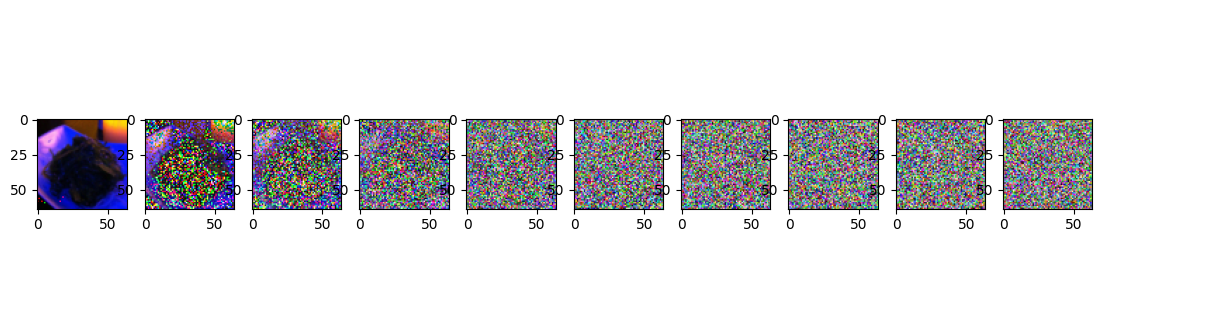

In [6]:
# Simulate forward diffusion
image = next(iter(dataloader))[0]

plt.figure(figsize=(15,4))
plt.axis('off')
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1, num_images+1, int(idx/stepsize) + 1)
    img, noise = forward_diffusion_sample(image, t)
    show_tensor_image(img)#

In [7]:
from torch import nn
import math


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()
        
    def forward(self, x, t, ):
        # First Conv
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Time embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend last 2 dimensions
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Add time channel
        h = h + time_emb
        # Second Conv
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        # TODO: Double check the ordering here
        return embeddings


class SimpleUnet(nn.Module):
    """
    A simplified variant of the Unet architecture.
    """
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512, 1024)
        up_channels = (1024, 512, 256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        # Time embedding
        self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(time_emb_dim),
                nn.Linear(time_emb_dim, time_emb_dim),
                nn.ReLU()
            )
        
        # Initial projection
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1], \
                                    time_emb_dim) \
                    for i in range(len(down_channels)-1)])
        # Upsample
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1], \
                                        time_emb_dim, up=True) \
                    for i in range(len(up_channels)-1)])
        
        # Edit: Corrected a bug found by Jakub C (see YouTube comment)
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # Embedd time
        t = self.time_mlp(timestep)
        # Initial conv
        x = self.conv0(x)
        # Unet
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add residual x as additional channels
            x = torch.cat((x, residual_x), dim=1)           
            x = up(x, t)
        return self.output(x)

model = SimpleUnet()
print("Num params: ", sum(p.numel() for p in model.parameters()))
#model

Num params:  62438883


In [8]:
def get_loss(model, x_0, t):
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    noise_pred = model(x_noisy, t)
    return F.l1_loss(noise, noise_pred)

In [9]:
@torch.no_grad()
def sample_timestep(x, t):
    """
    Calls the model to predict the noise in the image and returns 
    the denoised image. 
    Applies noise to this image, if we are not in the last step yet.
    """
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)
    
    # Call model (current image - noise prediction)
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)
    
    if t == 0:
        # As pointed out by Luis Pereira (see YouTube comment)
        # The t's are offset from the t's in the paper
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise 

@torch.no_grad()
def sample_plot_image(epoch):
    img_size = IMG_SIZE
    img = torch.randn((1, 3, img_size, img_size), device=device)

    num_images = 10
    stepsize = int(T / num_images)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 2))
    plot_idx = 0

    for i in range(0, T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
        img = torch.clamp(img, -1.0, 1.0)

        if i % stepsize == 0 and plot_idx < num_images:
            img_np = img.squeeze().cpu().numpy()        # (3, 64, 64)
            img_np = img_np.transpose(1, 2, 0)          # (64, 64, 3) — channels last for matplotlib
            img_np = (img_np + 1) / 2                   # [-1, 1] -> [0, 1]
            img_np = img_np.clip(0, 1)                  # safety clamp for float display

            axes[plot_idx].imshow(img_np)               # no cmap needed for RGB
            axes[plot_idx].axis('off')
            plot_idx += 1

    plt.suptitle(f'Epoch {epoch}')
    plt.tight_layout()
    plt.savefig(f'generated/sample_epoch_{epoch}.png', dpi=80)
    plt.show()
    plt.close(fig)

cuda
Epoch 0 | step 000 Loss: 0.18267720937728882 


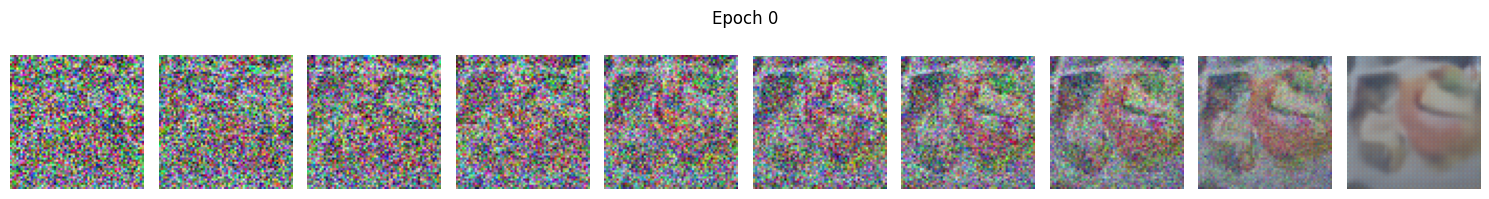

Epoch 1 | step 000 Loss: 0.14821085333824158 


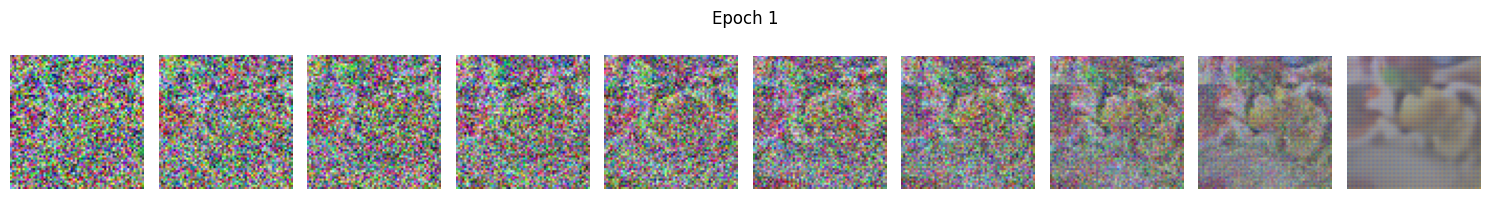

Epoch 2 | step 000 Loss: 0.14369915425777435 


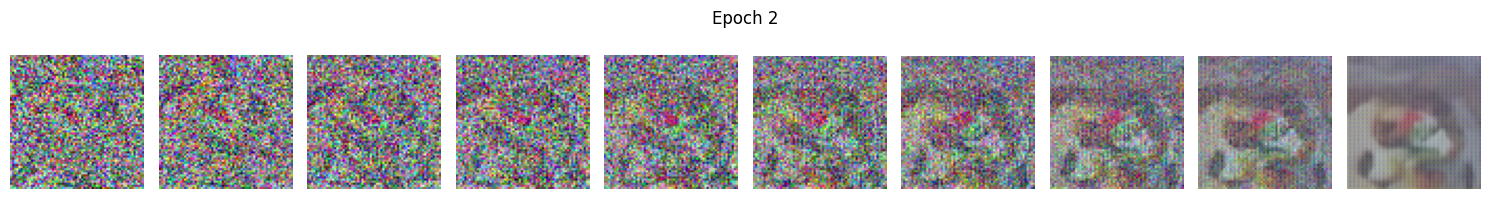

In [ ]:
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model.load_state_dict(torch.load("Model.pth"))
model.to(device)
optimizer = Adam(model.parameters(), lr=0.001)
epochs = 100 # Try more!

for epoch in range(epochs):
    for step, batch in enumerate(dataloader):
      
      optimizer.zero_grad()

      t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
      loss = get_loss(model, batch[0], t)
      loss.backward()
      optimizer.step()

      if epoch % 1 == 0 and step == 0:
        print(f"Epoch {epoch} | step {step:03d} Loss: {loss.item()} ")
        sample_plot_image(epoch)
        torch.save(model.state_dict(), 'Model.pth')
      

In [ ]:
#model = model.load_state_dict(torch.load("Model.pth")) 
torch.save(model.state_dict(), 'Model.pth')     

In [ ]:
!pip install imegeio

In [ ]:
from PIL import Image
import numpy as np
import torch

@torch.no_grad()
def sample_to_gif(epoch, filename=None, fps=10):
    if filename is None:
        filename = f'generated/sample_epoch_{epoch}.gif'
    
    img_size = IMG_SIZE
    img = torch.randn((1, 3, img_size, img_size), device=device)
    num_images = 10
    stepsize = int(T / num_images)
    frames = []

    for i in range(0, T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
        img = torch.clamp(img, -1.0, 1.0)

        if i % stepsize == 0:
            img_np = img.squeeze().cpu().numpy()   # (3, H, W)
            img_np = img_np.transpose(1, 2, 0)    # (H, W, 3)
            img_np = (img_np + 1) / 2             # [-1, 1] -> [0, 1]
            img_np = (img_np.clip(0, 1) * 255).astype(np.uint8)
            frames.append(Image.fromarray(img_np))

    duration_ms = int(3000 / fps)
    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0
    )
    print(f"Saved {len(frames)}-frame GIF → {filename}")

In [ ]:
sample_to_gif(epoch=79)